【Poolside/Laguna-XS.2】代码生成推理服务
====

> **Laguna XS.2 · 代码智能体**：Poolside 开源的 33B MoE（3B 激活参数）代码生成模型，
> 专为智能体编码（Agentic Coding）和长周期软件工程任务设计。
> 采用混合滑动窗口注意力（SWA）与全局注意力布局，支持 262K 超长上下文，
> 具备原生推理思考模式（Thinking）与工具调用能力。Apache 2.0 开源许可证。
> P2.gpu.large（80GB）完整加载 66GB BF16 权重。

## 一、项目简介

### 1.1 官方介绍

Laguna XS.2 是 Poolside 公司训练的开源代码生成模型，总参数量 330 亿，
采用混合专家（MoE）架构，每个 token 仅激活 30 亿参数。
模型在 40 层中的 30 层采用带每头门控的滑动窗口注意力（Sliding Window Attention），
以实现快速推理和低 KV 缓存需求。

Laguna XS.2 在 SWE-bench Verified 上达到 68.2%（4 次运行平均 pass@1），
在 Terminal-Bench 2.0 上达到 30.1%，在代码生成和工程任务方面表现优异。

### 1.2 本项目信息

| 项目属性 | 内容 |
|---------|------|
| **实现类型** | ① 推理 + WebUI（Gradio 可视化界面） |
| **模型名称** | Poolside/Laguna-XS.2 |
| **模型架构** | LagunaForCausalLM（自定义，trust_remote_code） |
| **参数量** | 33B MoE（3B 激活 / token） |
| **注意力机制** | 混合 SWA（30层滑动窗口 512 token）+ 10层全局注意力 |
| **上下文长度** | 262,144 tokens |
| **精度** | BF16（~66GB 完整权重） |
| **特有能力** | thinking 推理模式 / tool-call 工具调用 / 262K 上下文 |
| **许可证** | Apache 2.0（可商用） |

### 1.3 关键架构特点

- **MoE 架构**：256 个专家 + 1 个共享专家，每 token 激活 8 个专家
- **滑动窗口注意力**：30/40 层为 SWA（窗口 512），10/40 层为全局注意力
- **FP8 KV 缓存**：KV 缓存量化为 FP8，减少每个 token 的内存占用
- **原生推理**：支持思考过程（thinking）保留，工具调用间穿插思维

## 二、官方链接

| 类别 | 链接 |
|------|------|
| 🤗 HuggingFace | https://huggingface.co/poolside/Laguna-XS.2 |
| 📄 发布博客 | https://poolside.ai/blog/introducing-laguna-xs2-m1 |
| 🐙 GitHub（pool） | https://github.com/poolsideai/pool |
| 🦙 Ollama | https://ollama.com/library/laguna-xs.2 |
| 🇨🇳 hf-mirror 镜像 | https://hf-mirror.com/Poolside/Laguna-XS.2 |
| 🛠 vLLM 支持 | https://recipes.vllm.ai/poolside/Laguna-XS.2 |

## 三、算力推荐

| 配置 | 推荐 GPU | 显存要求 | 说明 |
|------|---------|:-------:|------|
| **最低配置** | A10 24GB | ≥ 24 GB | 需 CPU offload，模型加载 2-4h，推理极慢（<1 tok/s）|
| **推荐配置** | P2.gpu.large（80GB） | ≥ 80 GB | **推荐**，66GB BF16 权重完整加载，推理流畅 ~16 tok/s |

> ⚠️ 33B 总参数的 BF16 权重约 66GB，24GB 显存只能通过 CPU offload 运行，
> 每次推理需要从 CPU 搬运指定专家权重到 GPU，速度极慢。
> **强烈建议使用 80GB 显存规格。**

## 四、推理服务配置

| 配置项 | 参数值 |
|--------|--------|
| **transformers** | 5.12.1（必需 ≥ 5.7.0） |
| **模型挂载** | `/gemini/pretrain/Laguna-XS.2`（推理服务建软链 `/tmp/LagunaXS2`） |
| **代码目录** | `/gemini/code/` |
| **启动命令** | `bash /gemini/code/start.sh` |
| **服务端口** | 7860 |
| **访问路由** | `/` → Gradio WebUI |
| **推理引擎** | transformers 5.12.1 + accelerate 1.14.0 + device_map='auto' |
| **环境变量** | `TRANSFORMERS_OFFLINE=1`, `HF_ENDPOINT=https://hf-mirror.com` |
| **LD_LIBRARY_PATH** | 指向 `orion-cuda-X.X/libcudnn.so.9`（cuDNN 9） |

## 五、使用说明

### 5.1 WebUI 操作步骤

1. 打开推理服务地址（/），进入 Gradio WebUI 界面
2. 在输入框中输入编程问题（支持中英文）
3. （可选）在「参数」折叠面板中调整生成参数：
   - **Temperature**：0.0~1.5，默认 0.7。0.0 为贪心解码，确定性最强
   - **最大生成长度**：128~8192，默认 2048
4. 按回车键提交
5. 模型会先显示思考过程（thinking），再输出最终回答

> ⚠️ 首次加载模型约需 **2 小时**（后台加载中，页面可先打开），后续无需等待。
> 加载期间提问会提示「模型加载中」，请稍后再试。

### 5.5 WebUI 界面截图

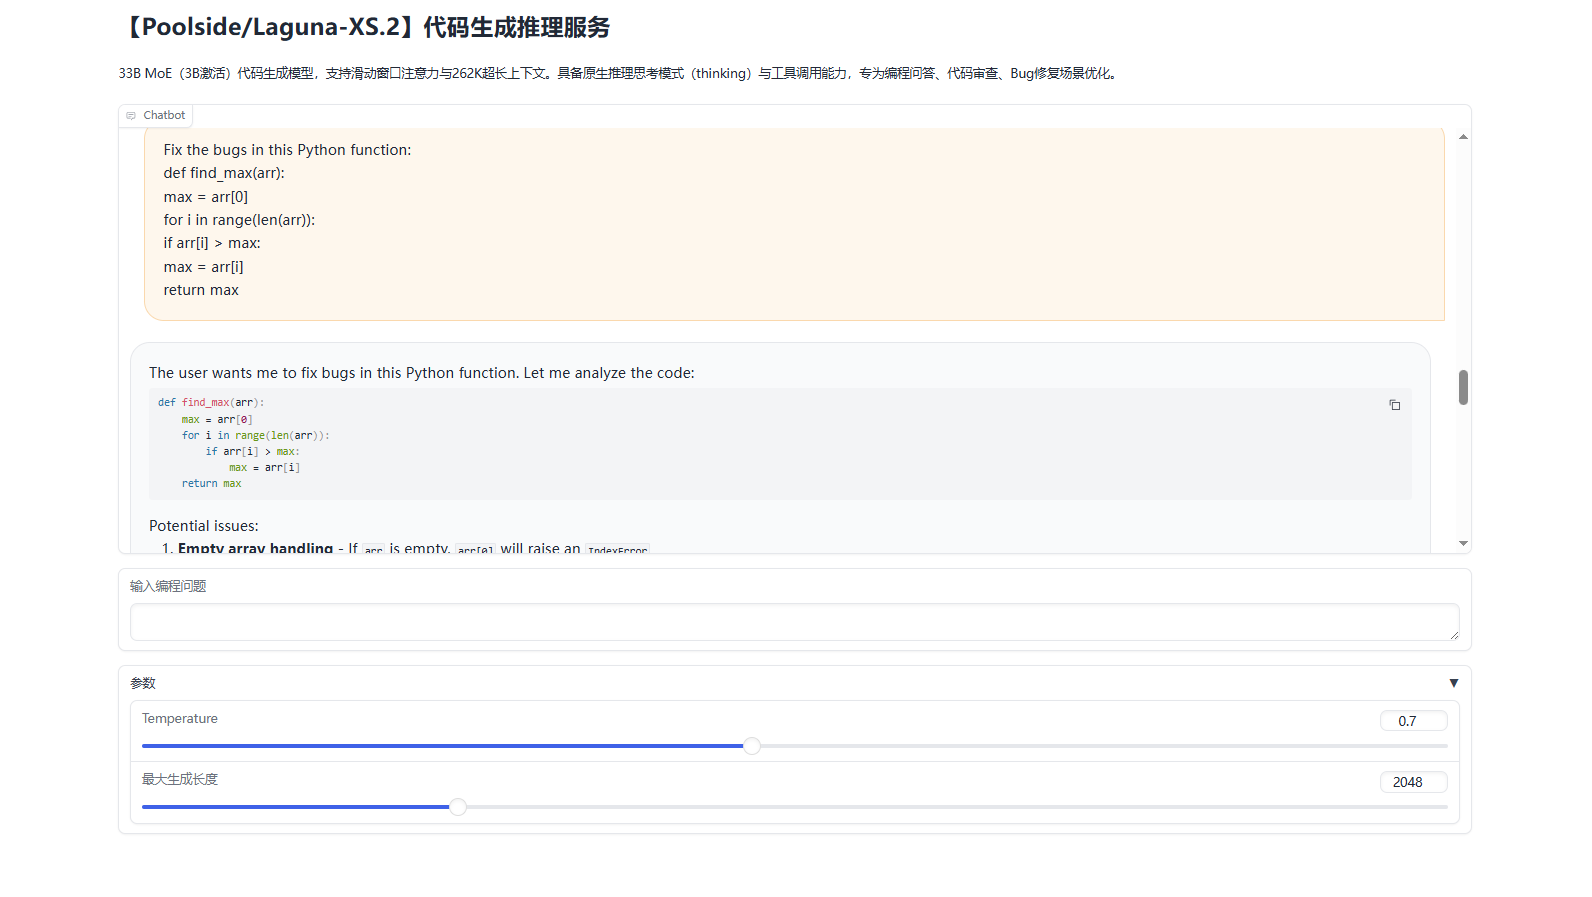


### 5.2 代码生成示例

Laguna XS.2 专为代码生成和智能体编码优化，支持以下场景：

**示例 1 —— 函数生成**
```
Write a Python class that implements a LRU cache with O(1) get and put operations.
Include thread-safe implementation.
```

**示例 2 —— Bug 修复**
```
Fix the bug in this function:
def find_max(arr):
    max = arr[0]
    for i in range(len(arr)):
        if arr[i] > max:
            max = arr[i]
    return max
```

**示例 3 —— 复杂算法**
```
Write a Python function to serialize and deserialize a binary tree.
```

**示例 4 —— 代码审查**
```
Review this code:
def process(data):
    r = []
    for i in data:
        if i not in r:
            r.append(i)
    return r
```

**示例 5 —— 多文件编辑（Agent 场景）**
```
Write a Python script that monitors a directory for new .csv files,
reads each one, validates schema, and writes invalid rows to error log.
```

### 5.3 API 调用示例

推理服务支持通过 Gradio API 远程调用：

```python
import requests

SERVER_URL = "https://your-service-url.com"

# 调用 Gradio API（/api/predict）
response = requests.post(
    f"{SERVER_URL}/api/predict",
    json={
        "data": [
            "Write a Python function to sort a list.",  # 编程问题
            [],  # 对话历史
            0.7,  # temperature
            512,  # max_new_tokens
        ]
    }
)

result = response.json()
print(result['data'][0])
```

### 5.4 注意事项

- **模型加载时间**：首次加载约需 2 小时（P2.gpu.large，80GB），33B 参数 ~66GB 权重从磁盘加载需要较长时间
- **后台加载机制**：推理服务启动后 Gradio 即刻可用（端口 7860），模型在后台线程加载，提问时若未加载完会提示等待
- **显存需求**：必须使用 80GB 显存规格，66GB BF16 权重需要 80GB 才能完整加载
- **模型路径**：模型目录名 `Laguna-XS.2` 含 `.`（点号），Python import 会解析失败。
  start.sh 启动时会自动在 `/tmp/` 下创建无点号的软链接 `/tmp/LagunaXS2`
- **thinking 模式**：默认启用思考模式，模型会先输出推理过程再给出回答。可在代码中通过 `enable_thinking=False` 关闭
- **多 EOS token**：模型有 `eos_token_id: [2, 24]` 两个结束符，代码使用 `model.config.eos_token_id` 正确传递列表
- **保活机制**：内置保活线程每 5 分钟 ping 本地服务，防止平台空闲超时杀进程
- **许可证**：Apache 2.0，可免费商用

## 六、模型评测结论

### 6.1 测试环境

| 项目 | 值 |
|------|------|
| **GPU** | P2.gpu.large |
| **总显存** | 80 GB |
| **模型参数量** | 33B MoE（3B 激活 / token） |
| **精度** | BF16 |
| **加载方式** | device_map='auto'，完整加载 ~66GB |
| **torch** | 2.5.1+cu121 |
| **transformers** | 5.12.1 |
| **测试参数** | max_new_tokens=512, temperature=0.7, 每场景 5 次 |

### 6.2 性能数据

| 场景 | 输入长度 | TTFT 平均 (ms) | 吞吐 (tok/s) |
|:----|:-------:|:------------:|:----------:|
| 短文本 | 14 字 | 408 | 15.8 |
| 中文本 | 25 字 | 254 | 16.9 |
| 长文本 | 30 字 | 257 | 16.9 |
| 超长文本 | 6000 字 | 706 | 15.2 |

### 6.3 核心结论

- **典型 TTFT**：250ms（中/长文本），交互体验流畅
- **吞吐**：~16.2 tok/s，80GB 上推理速度正常（3B 激活参数）
- **冷启动**：首次推理约 1050ms（GPU kernel 编译），后续稳定在 250ms
- **超长文本影响**：6000 字输入时 TTFT 升至 693ms，吞吐降至 15.2 tok/s
- **稳定性**：MoE 架构，256 专家/8 活跃，各场景延迟稳定，无异常抖动
- **模型质量**：通过 LRU Cache 等编程题目实测，回答完整含双链表+线程安全实现

> 📋 完整的性能评测数据详见 `LagunaXS2_benchmark_result.json`